# 2.2 Sequential Plots

In [48]:
import os
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = os.path.join(os.getcwd(), 'results')
BUDGETS = [1024, 2000, 4000, 8000, 16000, 32000]
CHARS_PER_TOKEN = 4.0

In [49]:
seq_records = []

for budget in BUDGETS:
    filepath = os.path.join(DATA_DIR, f'results_df_sequential_{budget}.csv')
    df = pd.read_csv(filepath)

    df['total_chars'] = df['model_output'].str.len()
    df['total_tokens_est'] = df['total_chars'] / CHARS_PER_TOKEN
    df['answer_tokens_est'] = (df['total_tokens_est'] - df['thinking_tokens']).clip(lower=0)
    df['total_tokens'] = df['thinking_tokens'] + df['answer_tokens_est']

    seq_records.append({
        'budget': budget,
        'thinking_mean': df['thinking_tokens'].mean(),
        'total_mean': df['total_tokens'].mean(),
        'exact_acc': df['exact_correct'].mean(),
        'flex_acc': df['flexible_correct'].mean(),
    })

seq_df = pd.DataFrame(seq_records)
print(seq_df[['budget', 'thinking_mean', 'total_mean', 'exact_acc', 'flex_acc']])

   budget  thinking_mean    total_mean  exact_acc  flex_acc
0    1024    1023.666667   2387.616667   0.200000  0.200000
1    2000    1999.700000   3051.600000   0.333333  0.333333
2    4000    3999.566667   4525.308333   0.366667  0.366667
3    8000    7998.133333   8170.341667   0.400000  0.433333
4   16000   15998.733333  16036.208333   0.733333  0.733333
5   32000   31998.500000  31998.500000   0.666667  0.666667


# Exact Accuracy vs. Thinking Tokens

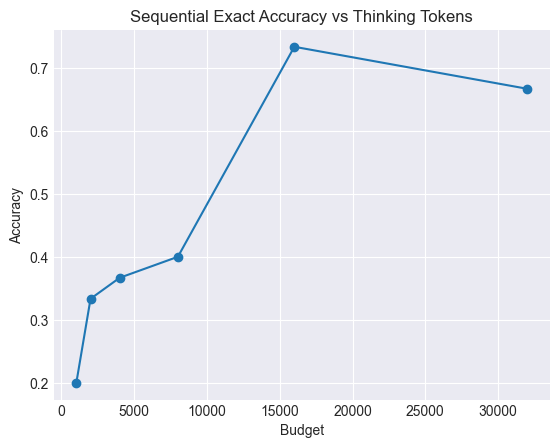

In [ ]:
import matplotlib.pyplot as plt

plt.plot(seq_df['budget'], seq_df['exact_acc'], 'o-')

plt.xlabel('Thinking Tokens')
plt.ylabel('Accuracy')
plt.title('Sequential Exact Accuracy vs Thinking Tokens')

plt.show()

## Plot: Flexible Accuracy vs Thinking Tokens

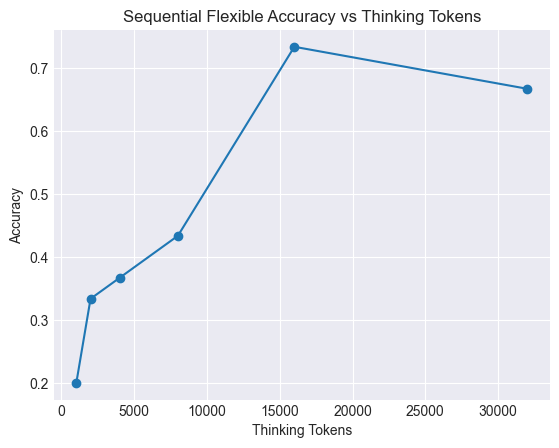

In [51]:
import matplotlib.pyplot as plt

plt.plot(seq_df['budget'], seq_df['flex_acc'], 'o-')

plt.xlabel('Thinking Tokens')
plt.ylabel('Accuracy')
plt.title('Sequential Flexible Accuracy vs Thinking Tokens')

plt.show()

# Exact Accuracy vs. Total Tokens

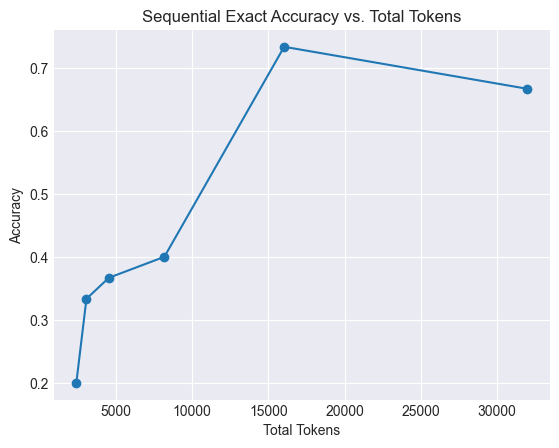

In [55]:
import matplotlib.pyplot as plt

plt.plot(seq_df['total_mean'], seq_df['exact_acc'], 'o-')

plt.xlabel('Total Tokens')
plt.ylabel('Accuracy')
plt.title('Sequential Exact Accuracy vs. Total Tokens')

plt.show()

# Flexible Accuracy vs Total Tokens

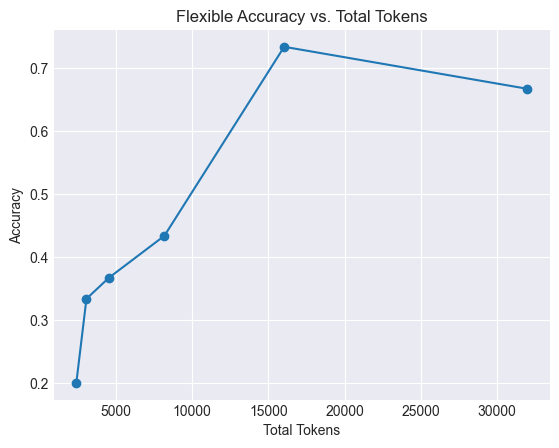

In [56]:
import matplotlib.pyplot as plt

plt.plot(seq_df['total_mean'], seq_df['flex_acc'], 'o-')

plt.xlabel('Total Tokens')
plt.ylabel('Accuracy')
plt.title('Flexible Accuracy vs. Total Tokens')

plt.show()